In [1]:
import csv
import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.svm import SVC
import scipy.sparse as sp
from sklearn.metrics import roc_auc_score

In [2]:
def load_toy_dataset_csv(file_path):
    X = []
    y = []
    
    with open(file_path, mode='r',encoding='utf-8') as f:
        reader = csv.reader(f)
        
        header = next(reader) 
        
        for row in reader:

            float_row = [float(val) for val in row]
            X.append(float_row[:-1])
            label = float_row[-1]
            y.append(1.0 if label == 1 else -1.0)
            
    return np.array(X), np.array(y)

In [3]:
def get_folds(X, y, k=5):
    indices = np.arange(len(y))
    np.random.shuffle(indices) 
    
    fold_sizes = np.full(k, len(y) // k)
    fold_sizes[:len(y) % k] += 1
    current = 0
    folds = []
    for size in fold_sizes:
        start, stop = current, current + size
        folds.append(indices[start:stop])
        current = stop
    return folds

def cross_validation(model_class, X, y, k=5, **model_params):
    folds = get_folds(X, y, k)
    scores = []
    
    for i in range(k):
        test_idx = folds[i]
        train_idx = np.concatenate([folds[j] for j in range(k) if j != i])
        
        X_train, y_train = X[train_idx], y[train_idx]
        X_test, y_test = X[test_idx], y[test_idx]
        
        model = model_class(**model_params)
        model.train(X_train, y_train)
        
        preds = model.predict(X_test)
        accuracy = np.mean(preds == y_test)
        scores.append(accuracy)
        
    return np.mean(scores), np.std(scores)

In [4]:
X_toy_t, y_toy_t = load_toy_dataset_csv(r'C:\Users\mande\Downloads\Datasets PA2-20260428\toydata_tiny.csv')

In [5]:
X_toy_l, y_toy_l = load_toy_dataset_csv(r'C:\Users\mande\Downloads\Datasets PA2-20260428\toydata_large.csv')

In [14]:
class LargeScaleSVM:
    def __init__(self, optimizer='sgd', lr=0.01, lambda_reg=0.01, batch_size=32, momentum=0.9):
        self.optimizer = optimizer
        self.lr = lr
        self.lambda_reg = lambda_reg
        self.batch_size = batch_size
        self.momentum_param = momentum
        self.w = None
        self.history = []

    def train(self, X, y, epochs=10):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        v = np.zeros(n_features)
        G = np.zeros(n_features)
        eps = 1e-8
        self.history = []
        y = np.asarray(y).flatten()

        for epoch in range(epochs):
            indices = np.random.permutation(n_samples)
            for i in range(0, n_samples, self.batch_size):
                batch_idx = indices[i : i + self.batch_size]
                X_batch = X[batch_idx]
                y_batch = y[batch_idx]
                
                grad = self.lambda_reg * self.w
                margins = y_batch * (X_batch.dot(self.w))
                mis_idx = np.where(margins < 1)[0]
                
                if len(mis_idx) > 0:
                    for idx in mis_idx:
                        xi = X_batch[idx]
                        yi = y_batch[idx]
                        
                        if hasattr(xi, "toarray"):
                            grad -= (yi * xi.toarray().flatten()) / self.batch_size
                        else:
                            grad -= (yi * xi) / self.batch_size
                
                
                if self.optimizer == 'sgd':
                    self.w -= self.lr * grad
                elif self.optimizer == 'momentum':
                    v = self.momentum_param * v + self.lr * grad
                    self.w -= v
                elif self.optimizer == 'adagrad':
                    G += grad**2
                    self.w -= (self.lr / (np.sqrt(G) + eps)) * grad
            
            self.history.append(self.calculate_loss(X, y))    
            

    def predict(self, X):
        return np.sign(X.dot(self.w))

    def calculate_loss(self, X, y):
        margins = y * (X.dot(self.w))
        hinge_loss = np.mean(np.maximum(0, 1 - margins))
        reg_loss = 0.5 * self.lambda_reg * np.dot(self.w, self.w)
        return hinge_loss + reg_loss

In [15]:
for opt in ['sgd', 'momentum', 'adagrad']:
    start_time = time.time()
    
    mean_acc, std_acc = cross_validation(
        LargeScaleSVM, 
        X_toy_t, 
        y_toy_t, 
        k=5, 
        optimizer=opt, 
        batch_size=32
    )
    
    duration = time.time() - start_time
    print(f"Result: {opt.upper()} -> Accuracy: {mean_acc:.4f} (+/- {std_acc:.4f}), Time: {duration:.2f}s")

Result: SGD -> Accuracy: 0.8100 (+/- 0.0515), Time: 0.07s
Result: MOMENTUM -> Accuracy: 0.9200 (+/- 0.0245), Time: 0.02s
Result: ADAGRAD -> Accuracy: 0.5000 (+/- 0.0866), Time: 0.03s


In [16]:
for opt in ['sgd', 'momentum', 'adagrad']:
    start_time = time.time()
    
    mean_acc, std_acc = cross_validation(
        LargeScaleSVM, 
        X_toy_l, 
        y_toy_l, 
        k=5, 
        optimizer=opt, 
        batch_size=32
    )
    
    duration = time.time() - start_time
    print(f"Result: {opt.upper()} -> Accuracy: {mean_acc:.4f} (+/- {std_acc:.4f}), Time: {duration:.2f}s")

Result: SGD -> Accuracy: 1.0000 (+/- 0.0000), Time: 6.16s
Result: MOMENTUM -> Accuracy: 0.9999 (+/- 0.0001), Time: 10.47s
Result: ADAGRAD -> Accuracy: 1.0000 (+/- 0.0000), Time: 25.80s


In [17]:
class RFFTransformer:
    def __init__(self, n_components=100, sigma=1.0, input_dim=None):
        self.n_components = n_components
        self.sigma = sigma
        self.W = None
        self.b = None
        self.input_dim = input_dim

    def fit(self, X):
    
        d = X.shape[1] if self.input_dim is None else self.input_dim
        
        self.W = (1.0 / self.sigma) * np.random.randn(d, self.n_components)
        
        self.b = np.random.uniform(0, 2 * np.pi, size=self.n_components)
        return self

    def transform(self, X):
        
        projection = np.dot(X, self.W) + self.b
        return np.sqrt(2.0 / self.n_components) * np.cos(projection)

In [18]:
rff = RFFTransformer(n_components=150, sigma=1.0)
rff.fit(X_toy_t)
X_rff = rff.transform(X_toy_t)

for opt in ['sgd', 'momentum', 'adagrad']:
    model = LargeScaleSVM(optimizer=opt, batch_size=32)
    model.train(X_rff, y_toy_t)
    
    preds = model.predict(X_rff)
    acc = np.mean(preds == y_toy_t)
    print(f"RFF SVM ({opt}): Accuracy = {acc:.4f}")

RFF SVM (sgd): Accuracy = 0.9950
RFF SVM (momentum): Accuracy = 0.9950
RFF SVM (adagrad): Accuracy = 0.9900


In [19]:
rff = RFFTransformer(n_components=150, sigma=1.0)
rff.fit(X_toy_l)
X_rff = rff.transform(X_toy_l)

for opt in ['sgd', 'momentum', 'adagrad']:
    model = LargeScaleSVM(optimizer=opt, batch_size=32)
    model.train(X_rff, y_toy_l)
    
    preds = model.predict(X_rff)
    acc = np.mean(preds == y_toy_l)
    print(f"RFF SVM ({opt}): Accuracy = {acc:.4f}")

RFF SVM (sgd): Accuracy = 0.7084
RFF SVM (momentum): Accuracy = 0.7077
RFF SVM (adagrad): Accuracy = 0.7071


In [20]:
def plot_convergence(X, y, optimizers=['sgd', 'momentum', 'adagrad']):
    plt.figure(figsize=(10, 6))
    for opt in optimizers:
        
        model = LargeScaleSVM(optimizer=opt, lr=0.01, batch_size=32)
        model.train(X, y, epochs=50) 
        plt.plot(model.history, label=f'Optimizer: {opt.upper()}')
    
    plt.title('Convergence Plots: Training Loss vs Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Hinge Loss + L2')
    plt.legend()
    plt.grid(True)
    plt.show()

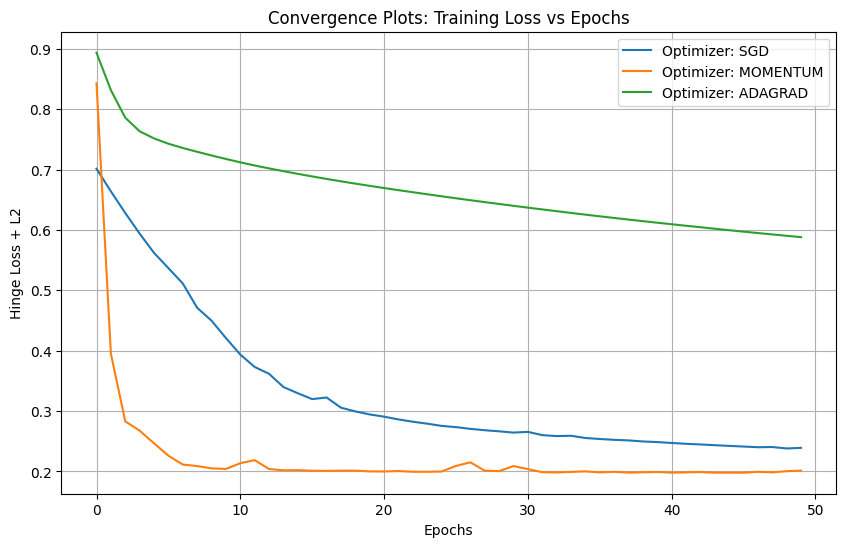

In [21]:
plot_convergence(X_toy_t, y_toy_t)

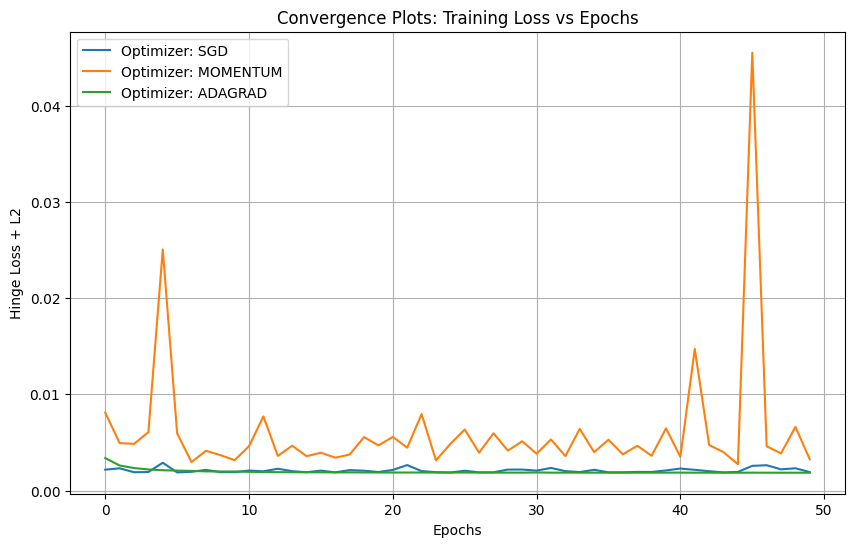

In [22]:
plot_convergence(X_toy_l, y_toy_l)

In [23]:
def compare_with_sklearn(X, y):
    
    start_rff = time.time()
    rff = RFFTransformer(n_components=150)
    rff.fit(X)
    X_rff = rff.transform(X)
    
    my_model = LargeScaleSVM(optimizer='momentum', lr=0.01)
    my_model.train(X_rff, y, epochs=50)
    
    my_preds = my_model.predict(X_rff)
    my_acc = np.mean(my_preds == y)
    print(f"My RFF-SVM: Accuracy = {my_acc:.4f}, Time = {time.time() - start_rff:.2f}s")
    
    start_sk = time.time()
    sk_model = SVC(kernel='rbf') 
    sk_model.fit(X, y)
    
    sk_preds = sk_model.predict(X)
    sk_acc = np.mean(sk_preds == y)
    print(f"Sklearn SVC: Accuracy = {sk_acc:.4f}, Time = {time.time() - start_sk:.2f}s")

In [24]:
compare_with_sklearn(X_toy_t, y_toy_t)

My RFF-SVM: Accuracy = 0.9900, Time = 0.06s
Sklearn SVC: Accuracy = 0.9950, Time = 0.00s


In [25]:
compare_with_sklearn(X_toy_l, y_toy_l)

My RFF-SVM: Accuracy = 0.5799, Time = 141.90s
Sklearn SVC: Accuracy = 1.0000, Time = 2.91s


In [26]:
def load_imdb(file_path):
    data = np.load(file_path, allow_pickle=True)
    
    X_train = data['train'].item()
    y_train = data['train_labels']
    X_test = data['test'].item()
    y_test = data['test_labels']
    
    y_train = np.where(y_train == 0, -1, 1)
    y_test = np.where(y_test == 0, -1, 1)
    
    return X_train, y_train, X_test, y_test

X_train_imdb, y_train_imdb, X_test_imdb, y_test_imdb = load_imdb(r'C:\Users\mande\Downloads\Datasets PA2-20260428\imdb.npz')

In [27]:
for opt in ['sgd', 'momentum', 'adagrad']:
    start_time = time.time()
    
    model = LargeScaleSVM(optimizer=opt, lr=0.001, batch_size=64)
    model.train(X_train_imdb, y_train_imdb, epochs=10)
    
    preds = model.predict(X_test_imdb)
    acc = np.mean(preds == y_test_imdb)
    
    scores = X_test_imdb.dot(model.w)
    auc = roc_auc_score(y_test_imdb, scores)
    
    duration = time.time() - start_time
    print(f"{opt.upper()}: Accuracy = {acc:.4f}, AUC = {auc:.4f}, Time = {duration:.2f}s")

SGD: Accuracy = 0.4998, AUC = 0.7373, Time = 166.83s
MOMENTUM: Accuracy = 0.4998, AUC = 0.7373, Time = 82.12s
ADAGRAD: Accuracy = 0.5016, AUC = 0.8450, Time = 102.80s


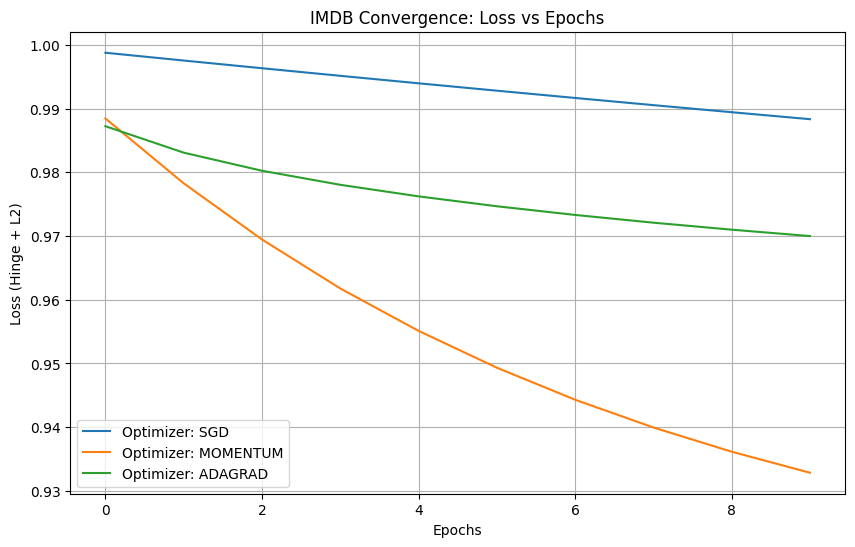

In [21]:
plt.figure(figsize=(10, 6))
for opt in ['sgd', 'momentum', 'adagrad']:

    model = LargeScaleSVM(optimizer=opt, lr=0.001, batch_size=64)
    model.train(X_train_imdb, y_train_imdb, epochs=10) 
    plt.plot(model.history, label=f'Optimizer: {opt.upper()}')

plt.title('IMDB Convergence: Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss (Hinge + L2)')
plt.legend()
plt.grid(True)
plt.show()

In [22]:
def load_higgs(file_path):
    data = np.load(file_path)
    
    X_train = data['train']
    y_train = data['train_labels']
    X_test = data['test']
    y_test = data['test_labels']
    
    y_train = np.where(y_train == 0, -1, 1)
    y_test = np.where(y_test == 0, -1, 1)
    
    return X_train, y_train, X_test, y_test

X_train_higgs, y_train_higgs, X_test_higgs, y_test_higgs = load_higgs(r'C:\Users\mande\Downloads\higgs.npz')

In [24]:
for b_size in [8, 32, 128]:
    start_time = time.time()
    
    model = LargeScaleSVM(optimizer='momentum', lr=0.001, batch_size=b_size)
    model.train(X_train_higgs, y_train_higgs, epochs=1) 
    
    scores = X_test_higgs.dot(model.w)
    auc_val = roc_auc_score(y_test_higgs, scores)
    
    duration = time.time() - start_time
    print(f"Batch Size {b_size:3} | AUC: {auc_val:.4f} | Time: {duration:.2f}s")

Batch Size   8 | AUC: 0.6589 | Time: 157.61s
Batch Size  32 | AUC: 0.6611 | Time: 95.14s
Batch Size 128 | AUC: 0.6636 | Time: 80.55s
